# ***Procurement Invoice Fraud Detection***

## *Objective*
Develop a machine learning pipeline to detect fraudulent procurement invoices using structured invoice, supplier, department, and behavioural data. The notebook covers data preprocessing, feature engineering, model development, hyperparameter tuning, evaluation, and model export.

### *Workflow*
1. Data Loading
2. Exploratory Data Analysis
3. Feature Engineering
4. Data Preprocessing
5. Data Preparation
6. Model Development (Best Baseline Models)
7. Hyperparameter Tuning for selected baseline models
8. Model Evaluation & Selection of best model
9. Model Export


### **Setup & Imports**

In [ ]:
!pip install pyarrow fastparquet -q

In [150]:
!pip install catboost -q

In [151]:
# ==========================================
# Standard Libraries
# ==========================================
import os
import zipfile
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ==========================================
# Data Manipulation
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ==========================================
# Machine Learning
# ==========================================
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ==========================================
# Model Persistence
# ==========================================
import joblib
import sys

RANDOM_STATE = 42


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Version Checking**

In [16]:
print(sklearn.__version__)
print(joblib.__version__)
print(sys.version)
print(xgb.__version__)
print(pd.__version__)
print(np.__version__)
print(sns.__version__)

1.6.1
1.5.3
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
3.3.0
2.2.2
2.0.2
0.13.2


### **Dataset Loading**

In [223]:
ZIP_PATH = "/content/drive/MyDrive/CDAC_ML_Project/archive (6).zip"
EXTRACT_PATH = "/content/procurement_fraud_dataset"

if not os.path.exists(EXTRACT_PATH):
    print("Extracting ZIP file...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Extraction completed.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


### **Loading the parquet files**

In [224]:
parquet_files = list(Path(EXTRACT_PATH).rglob("*.parquet"))
print("Total Parquet Files:", len(parquet_files))
for f in parquet_files:
    print(" -", f)

Total Parquet Files: 7
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/labels.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/images_metadata.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/splits.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/invoices.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/behavioural_features.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/departments.parquet
 - /content/procurement_fraud_dataset/Procument Invoice Fraud Dataset v1/suppliers.parquet


### **Reading every dataframe**

In [225]:
dataframes = {
    file.stem: pd.read_parquet(file)
    for file in parquet_files
}

print("Loaded datasets:")
for name, df in dataframes.items():
    print(f"{name}: {df.shape}")

Loaded datasets:
labels: (300000, 5)
images_metadata: (45000, 4)
splits: (300000, 2)
invoices: (300000, 10)
behavioural_features: (300000, 7)
departments: (50, 3)
suppliers: (2000, 6)


### **Dataset Overview -  EDA (all tables)**

* A reusable profiling function so you get the same consistent report for every table
(shape, dtypes, missing values, duplicate rows, unique counts, and a preview).

In [226]:
'''
def profile_dataframe(df, name):
    print("=" * 100)
    print("DATASET:", name)
    print("=" * 100)

    print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")

    print("\nColumn dtypes:")
    print(df.dtypes)

    print("\nMissing values (count / %):")
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_df = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
    print(miss_df[miss_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
          if miss.sum() > 0 else "  none")

    print(f"\nDuplicate rows: {df.duplicated().sum():,}")

    print("\nUnique value counts per column:")
    print(df.nunique())

    print("\nPreview:")
    display(df.head())
    print("\n")


for name, df in dataframes.items():
    profile_dataframe(df, name)
'''



'\ndef profile_dataframe(df, name):\n    print("=" * 100)\n    print("DATASET:", name)\n    print("=" * 100)\n\n    print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")\n\n    print("\nColumn dtypes:")\n    print(df.dtypes)\n\n    print("\nMissing values (count / %):")\n    miss = df.isnull().sum()\n    miss_pct = (miss / len(df) * 100).round(2)\n    miss_df = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})\n    print(miss_df[miss_df["missing_count"] > 0].sort_values("missing_count", ascending=False)\n          if miss.sum() > 0 else "  none")\n\n    print(f"\nDuplicate rows: {df.duplicated().sum():,}")\n\n    print("\nUnique value counts per column:")\n    print(df.nunique())\n\n    print("\nPreview:")\n    display(df.head())\n    print("\n")\n\n\nfor name, df in dataframes.items():\n    profile_dataframe(df, name)\n'

### **Shard Keys**
* Tells us how the different datasets are related to eachother

In [227]:
'''
names = list(dataframes.keys())
print("Shared columns between tables (likely join keys):\n")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        common = set(dataframes[names[i]].columns) & set(dataframes[names[j]].columns)
        if common:
            print(f"{names[i]}  <-->  {names[j]}  :  {common}")
'''

'\nnames = list(dataframes.keys())\nprint("Shared columns between tables (likely join keys):\n")\nfor i in range(len(names)):\n    for j in range(i + 1, len(names)):\n        common = set(dataframes[names[i]].columns) & set(dataframes[names[j]].columns)\n        if common:\n            print(f"{names[i]}  <-->  {names[j]}  :  {common}")\n'

### **Extract important tables**

In [228]:
labels = dataframes.get("labels")
invoices = dataframes.get("invoices")
behavioural = dataframes.get("behavioural_features")
splits = dataframes.get("splits")

TARGET = "is_fraud"          # binary fraud flag
FRAUD_TYPE_COL = "fraud_type"  # multi-class fraud category (NaN/"none" for legit invoices)
KEY = "invoice_id"



### **Build a Master Dataframe**

* Merge everything onto `invoice_id` so every downstream analysis has full context
(invoice details + behavioural features + label + split) in a single table.
* Adjust the join keys below if your table names/columns differ.

In [229]:
master = invoices.copy()

master = (
    dataframes["invoices"]
        .merge(dataframes["behavioural_features"], on="invoice_id", how="left")
        .merge(dataframes["labels"], on="invoice_id", how="left")
        .merge(dataframes["splits"], on="invoice_id", how="left")
        .merge(dataframes["suppliers"], on="supplier_id", how="left")
        .merge(dataframes["departments"], on="department_id", how="left")
)

print("Master Dataset Shape:", master.shape)
master.head()

Master Dataset Shape: (300000, 28)


,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,image_path,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag,is_fraud,fraud_type,fraud_tags,explanations,split,supplier_country,supplier_age_days,supplier_risk_score,blacklisted_flag,avg_invoice_amount,region,annual_budget
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,data/v1/20251214_172643/images/INV_0000000.png,13.0,5417.982105,-0.453822,0,0,0,0,NONE,,"{""reason"": ""NONE""}",train,CA,1468,0.219,0,4552.54,North Carolina,2.171350e+07
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,None,6.0,6745.242333,0.261806,0,0,0,0,NONE,,"{""reason"": ""NONE""}",val,SV,484,0.083,0,5568.13,Arizona,4.778807e+08
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,None,13.0,4950.948095,0.109614,0,0,0,0,NONE,,"{""reason"": ""NONE""}",val,MR,238,0.198,0,4542.37,Connecticut,5.119035e+07
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,None,15.0,3524.075116,-0.702008,0,1,0,1,SPLIT,SPLIT,"{""rules"": [""SPLIT""]}",val,SR,2523,0.382,0,2705.89,Pennsylvania,7.018474e+06
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,None,11.0,4670.320968,-0.589080,0,0,0,0,NONE,,"{""reason"": ""NONE""}",train,TV,153,0.139,0,3590.46,Louisiana,2.118290e+08


### **EDA on master dataset**

***1. Dataset Overview***

In [230]:
#=================================================
# Dataset Overview
#=================================================
master.shape
master.head()
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   invoice_id                  300000 non-null  object        
 1   supplier_id                 300000 non-null  object        
 2   department_id               300000 non-null  object        
 3   invoice_date                300000 non-null  datetime64[ns]
 4   invoice_amount              300000 non-null  float64       
 5   currency                    300000 non-null  object        
 6   payment_terms               300000 non-null  object        
 7   invoice_type                300000 non-null  object        
 8   submission_hour             300000 non-null  int64         
 9   image_path                  45000 non-null   object        
 10  supplier_invoice_count_30d  300000 non-null  float64       
 11  supplier_avg_amount_90d     300000 non-

***2. Missing Value Analysis***

In [231]:
#=================================================
# Missing Values
#=================================================

missing = (
    master.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

,0
image_path,255000


***3. Duplicate Analysis***

In [232]:
print(master.duplicated().sum())
print(master["invoice_id"].duplicated().sum())

0
0


***4.1. Class Balance Analysis***

* This is the core question: **how imbalanced is this dataset?**
* Fraud datasets are almost
always heavily skewed toward the negative class, which affects everything downstream —
metric choice, resampling strategy, and how you interpret model performance.

In [233]:
#===============================================
# Class-Distribution
#===============================================

fraud_counts = labels[TARGET].value_counts().sort_index()
fraud_pct = (
    labels[TARGET]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(3)

balance_summary = pd.DataFrame({
    "count": fraud_counts,
    "percentage": fraud_pct
})

display(balance_summary)

,count,percentage
is_fraud,,
0,233590,77.863
1,66410,22.137


***4.2. Count Plot***

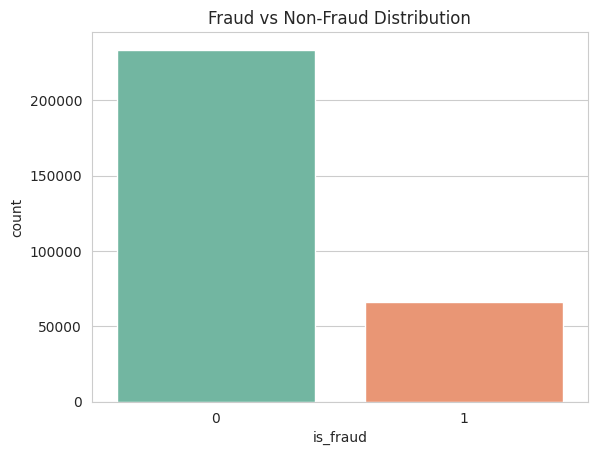

In [234]:
sns.countplot(
    x=labels[TARGET],
    palette="Set2"
)

plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

***4.3. Split Consistency***
* Checks if the imbalance is consistent across train/val/test splits
* *Important: Stratified splits should preserve the same fraud rate in every split*

is_fraud,0,1
split,,
test,77.48,22.52
train,78.03,21.97
val,77.42,22.58


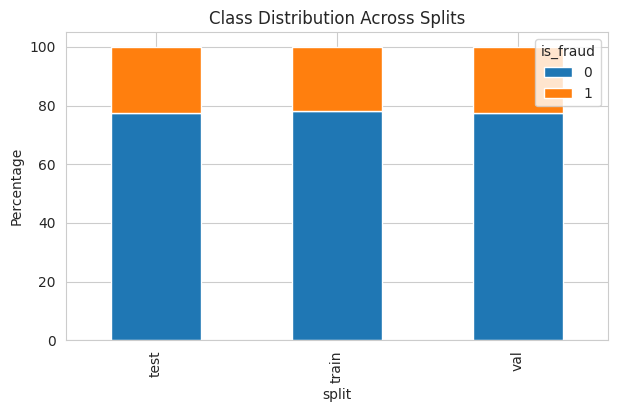

In [235]:
labels_splits = labels.merge(
    splits,
    on="invoice_id"
)

split_distribution = pd.crosstab(
    labels_splits["split"],
    labels_splits[TARGET],
    normalize="index"
) * 100

display(split_distribution.round(2))

split_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.ylabel("Percentage")
plt.title("Class Distribution Across Splits")
plt.show()

***5. Numeric Feature Analysis***



In [240]:
numeric_cols = master.select_dtypes(include=["int64", "float64"]).columns

In [241]:
master[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
invoice_amount,300000.0,7.564709e+03,8.812143e+03,3.735000e+01,2.641758e+03,4.892300e+03,9.166188e+03,2.940487e+05
submission_hour,300000.0,1.148524e+01,6.922530e+00,0.000000e+00,5.000000e+00,1.100000e+01,1.700000e+01,2.300000e+01
supplier_invoice_count_30d,300000.0,1.263589e+01,3.918758e+00,1.000000e+00,1.000000e+01,1.300000e+01,1.500000e+01,3.100000e+01
supplier_avg_amount_90d,300000.0,7.572865e+03,6.240050e+03,1.933300e+02,3.654073e+03,5.767309e+03,9.358080e+03,2.940487e+05
invoice_amount_zscore,300000.0,5.570655e-17,1.000002e+00,-8.542044e-01,-5.586563e-01,-3.032648e-01,1.817357e-01,3.251019e+01
duplicate_invoice_flag,300000.0,2.333333e-04,1.527350e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
split_invoice_flag,300000.0,1.422633e-01,3.493206e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
late_night_submission_flag,300000.0,2.505467e-01,4.333286e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
is_fraud,300000.0,2.213667e-01,4.151675e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
supplier_age_days,300000.0,2.259979e+03,1.567266e+03,3.000000e+01,8.040000e+02,2.243000e+03,3.629000e+03,4.999000e+03


***6. Categorical / Flag Feature Analysis***

For every boolean flag and categorical column, look at the fraud rate within each category.
This is usually where the strongest fraud signals live (e.g. `late_night_submission_flag`,
`split_invoice_flag`, `duplicate_invoice_flag`).

In [242]:
categorical_cols = master.select_dtypes(include=["object"]).columns


In [243]:
for col in categorical_cols:
    display(master[col].value_counts().head())

,count
invoice_id,
INV_0299983,1
INV_0299982,1
INV_0299981,1
INV_0299980,1
INV_0299979,1


,count
supplier_id,
04aac1b7-5ca0-4428-822c-4d326c645c15,201
65d0b517-88d0-4abd-8bb1-8c791036708d,193
61542765-d756-4a9c-864c-96479ea7017c,192
654c11d9-f2e6-4828-81bb-819c4dfe1117,191
d7665cda-fe04-4059-b985-fb6217dc8eff,190


,count
department_id,
DPT_013,6143
DPT_009,6132
DPT_039,6103
DPT_036,6099
DPT_044,6097


,count
currency,
ZAR,300000


,count
payment_terms,
NET30,180337
NET60,89883
NET90,29780


...

,count
fraud_tags,
,237036
SPLIT,40201
GHOST_SUPPLIER,12588
INFLATED,5121
SPLIT;GHOST_SUPPLIER,2144


,count
explanations,
"{""reason"": ""NONE""}",237036
"{""rules"": [""SPLIT""]}",40201
"{""rules"": [""GHOST_SUPPLIER""]}",12588
"{""rules"": [""INFLATED""]}",5121
"{""rules"": [""SPLIT"", ""GHOST_SUPPLIER""]}",2144


,count
split,
train,210000
test,60000
val,30000


,count
supplier_country,
KZ,6207
IN,6088
DZ,5421
DE,5365
CU,5309


,count
region,
Arkansas,29952
Connecticut,29939
New York,23845
Louisiana,18126
Nevada,18058


***7. Correlation Analysis***

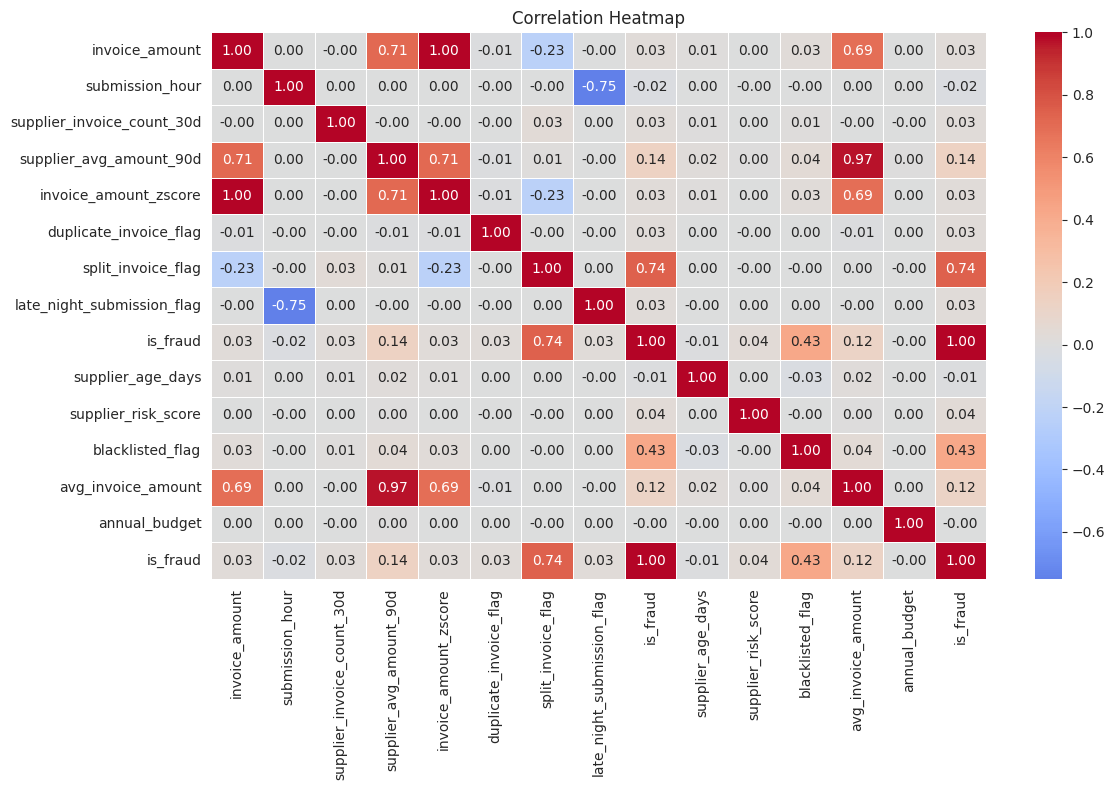

In [244]:
# ==========================================
# Correlation Analysis
# ==========================================

corr_cols = [
    col for col in numeric_cols
    if master[col].nunique() > 1
]

corr_matrix = master[corr_cols + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

***8. Important Feature Analysis***

In [249]:
# ==========================================
# Important Feature Distributions
# ==========================================

important_features = [
    "total_amount",
    "payment_terms",
    "invoice_type",
    "payment_delay_days"
]

In [250]:
important_features = [
    col for col in important_features
    if col in master.columns
]

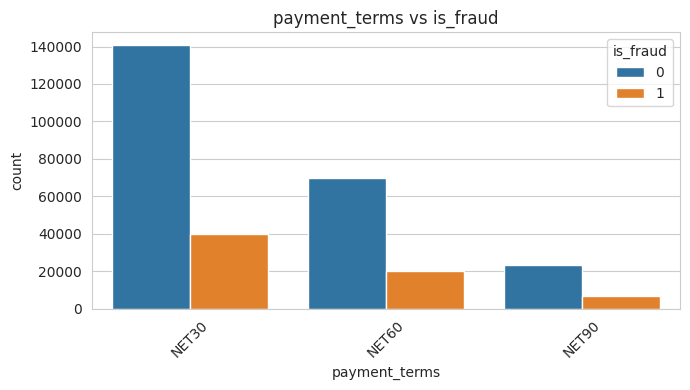

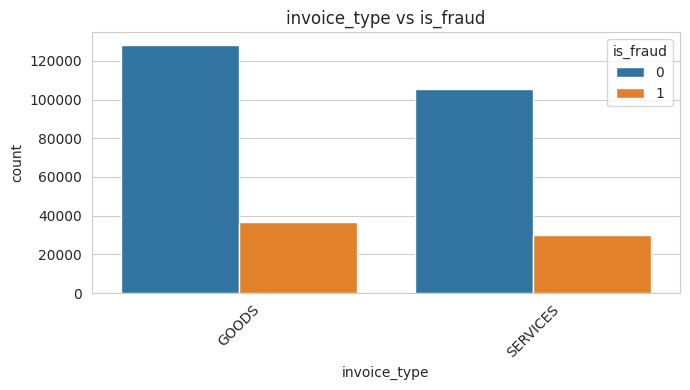

In [251]:
for feature in important_features:

    plt.figure(figsize=(7,4))

    if feature in numeric_cols:

        sns.histplot(
            data=master,
            x=feature,
            hue=TARGET,
            kde=True,
            bins=30,
            element="step"
        )

    else:

        order = master[feature].value_counts().index

        sns.countplot(
            data=master,
            x=feature,
            hue=TARGET,
            order=order
        )

        plt.xticks(rotation=45)

    plt.title(f"{feature} vs {TARGET}")

    plt.tight_layout()
    plt.show()

***9. Time-Based Analysis - Monthly Fraud Trend***

* Fraud often clusters around specific times (e.g. late-night submissions, month-end,
end-of-quarter budget flushing).

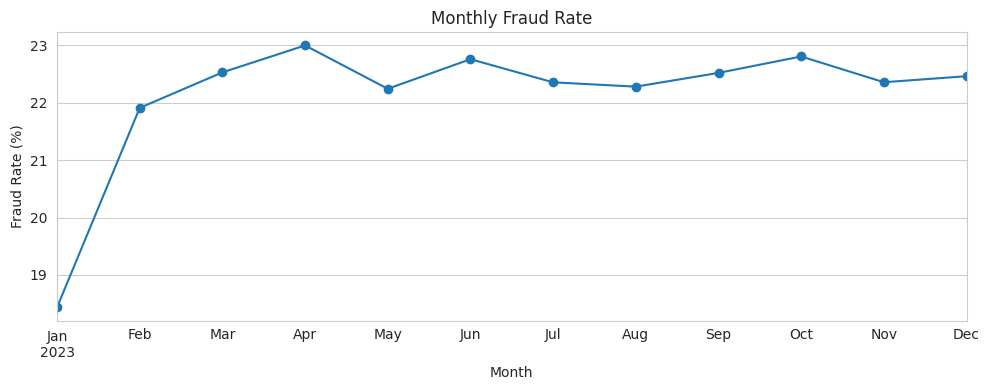

In [252]:
if "invoice_date" in master.columns:

    master["invoice_date"] = pd.to_datetime(master["invoice_date"])

    monthly_fraud = (
        master.groupby(master["invoice_date"].dt.to_period("M"))[TARGET]
        .mean() * 100
    )

    plt.figure(figsize=(10,4))

    monthly_fraud.plot(marker="o")

    plt.title("Monthly Fraud Rate")
    plt.ylabel("Fraud Rate (%)")
    plt.xlabel("Month")

    plt.tight_layout()
    plt.show()

***10. Dataset Split Distribution***

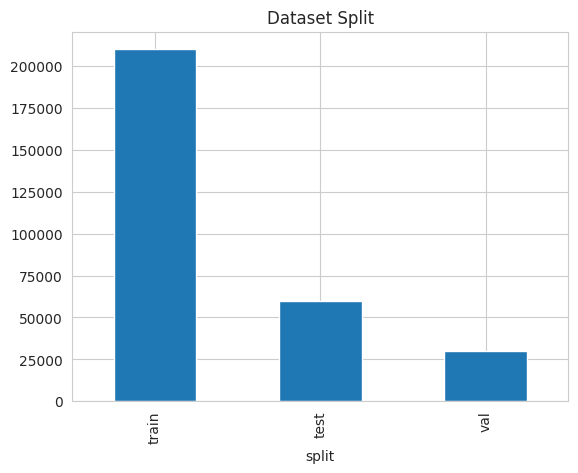

In [253]:
master["split"].value_counts().plot(kind="bar")

plt.title("Dataset Split")
plt.show()

### **Feature Engineering**

***1. Create Date Features***

In [254]:
master["invoice_month"] = master["invoice_date"].dt.month
master["invoice_weekday"] = master["invoice_date"].dt.dayofweek
master["invoice_quarter"] = master["invoice_date"].dt.quarter
master["is_weekend"] = (master["invoice_weekday"] >= 5).astype(int)

**2. Numerical Feature Summary**

In [255]:
# Numerical Feature Summary
numerical_cols = master.select_dtypes(include=np.number).columns

display(master[numerical_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
invoice_amount,300000.0,7.564709e+03,8.812143e+03,3.735000e+01,2.641758e+03,4.892300e+03,9.166188e+03,2.940487e+05
submission_hour,300000.0,1.148524e+01,6.922530e+00,0.000000e+00,5.000000e+00,1.100000e+01,1.700000e+01,2.300000e+01
supplier_invoice_count_30d,300000.0,1.263589e+01,3.918758e+00,1.000000e+00,1.000000e+01,1.300000e+01,1.500000e+01,3.100000e+01
supplier_avg_amount_90d,300000.0,7.572865e+03,6.240050e+03,1.933300e+02,3.654073e+03,5.767309e+03,9.358080e+03,2.940487e+05
invoice_amount_zscore,300000.0,5.570655e-17,1.000002e+00,-8.542044e-01,-5.586563e-01,-3.032648e-01,1.817357e-01,3.251019e+01
duplicate_invoice_flag,300000.0,2.333333e-04,1.527350e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
split_invoice_flag,300000.0,1.422633e-01,3.493206e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
late_night_submission_flag,300000.0,2.505467e-01,4.333286e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
is_fraud,300000.0,2.213667e-01,4.151675e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
supplier_age_days,300000.0,2.259979e+03,1.567266e+03,3.000000e+01,8.040000e+02,2.243000e+03,3.629000e+03,4.999000e+03


***3. Categorical Feature Summary***

In [256]:
categorical_cols = master.select_dtypes(include="object").columns

display(master[categorical_cols].describe().T)

,count,unique,top,freq
invoice_id,300000,300000,INV_0299983,1
supplier_id,300000,2000,04aac1b7-5ca0-4428-822c-4d326c645c15,201
department_id,300000,50,DPT_013,6143
currency,300000,1,ZAR,300000
payment_terms,300000,3,NET30,180337
invoice_type,300000,2,GOODS,164863
image_path,45000,45000,data/v1/20251214_172643/images/INV_0299983.png,1
fraud_type,300000,6,NONE,237036
fraud_tags,300000,16,,237036
explanations,300000,16,"{""reason"": ""NONE""}",237036


***4. Drop Unnecessary Columns***

In [257]:
drop_cols = [

    # Identifiers
    "invoice_id",
    "department_id",

    # Image Path
    "image_path",

    # Target-related columns
    "fraud_type",
    "fraud_tags",
    "explanations",

    # replaced by engineered date features
    "invoice_date",

    # only one unique value
    "currency",

    # only used to create train/val/test
    "split",

    # Dataset-specific flags
    "duplicate_invoice_flag",
    "split_invoice_flag"
]


***5. Create Final Training Dataset***

In [114]:
master_model = master.drop(columns=drop_cols)

In [117]:
master_model.columns


Index(['supplier_id', 'invoice_amount', 'payment_terms', 'invoice_type', 'submission_hour', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d', 'invoice_amount_zscore',
       'late_night_submission_flag', 'is_fraud', 'supplier_country', 'supplier_age_days', 'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount', 'region', 'annual_budget', 'invoice_month',
       'invoice_weekday', 'invoice_quarter', 'is_weekend'],
      dtype='object')

***6. Export Training Dataset***

In [118]:
# Export final dataset for PostgreSQL

master_model.to_csv("training_invoices.csv", index=False)

print("Training dataset exported successfully!")
print(f"Shape: {master_model.shape}")

Training dataset exported successfully!
Shape: (300000, 21)


### **Data Preparation**

***1. Train / Validation / Test Split***

In [119]:
train_df = master[master["split"] == "train"].copy()
val_df = master[master["split"] == "val"].copy()
test_df = master[master["split"] == "test"].copy()

In [120]:
drop_cols = [
    "invoice_date",
    "currency",
    "split",
    "duplicate_invoice_flag",
    "split_invoice_flag"
]

train_df.drop(columns=drop_cols, inplace=True)
val_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

***3. Frequency Encoding for `supplier_id`***

In [121]:
supplier_freq = train_df["supplier_id"].value_counts()

train_df["supplier_frequency"] = (
    train_df["supplier_id"]
    .map(supplier_freq)
)

val_df["supplier_frequency"] = (
    val_df["supplier_id"]
    .map(supplier_freq)
    .fillna(0)
)

test_df["supplier_frequency"] = (
    test_df["supplier_id"]
    .map(supplier_freq)
    .fillna(0)
)

***Q. Why feature engineering step after splitting?***
* Frequency encoding is a feature engineering technique, but unlike date-based features, it depends on the distribution of the data.
* If I computed supplier frequencies on the entire dataset before splitting, information from the validation and test sets would leak into the training process.
* To avoid data leakage, I first split the data and then calculated supplier frequencies using only the training set.
* The learned frequencies were then mapped to the validation and test sets, assigning unseen suppliers a frequency of 0.

In [132]:
print(X_train.select_dtypes(include="object").columns.tolist())

['invoice_id', 'department_id', 'payment_terms', 'invoice_type', 'image_path', 'fraud_type', 'fraud_tags', 'explanations', 'supplier_country', 'region']


In [133]:
drop_cols = [
    "invoice_id",
    "department_id",
    "image_path",
    "fraud_type",
    "fraud_tags",
    "explanations",
    "invoice_date",
    "currency",
    "split",
    "duplicate_invoice_flag",
    "split_invoice_flag"
]

train_df = train_df.drop(columns=drop_cols, errors="ignore")
val_df   = val_df.drop(columns=drop_cols, errors="ignore")
test_df  = test_df.drop(columns=drop_cols, errors="ignore")

***4. Create Features & Target***

In [137]:
X_train = train_df.drop(columns=["is_fraud"])
y_train = train_df["is_fraud"]

X_val = val_df.drop(columns=["is_fraud"])
y_val = val_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

In [138]:
print(f"Train : {X_train.shape},{y_train.shape}")
print(f"Validation : {X_val.shape},{y_val.shape}")
print(f"Test : {X_test.shape},{y_test.shape}")

Train : (210000, 21),(210000,)
Validation : (30000, 21),(30000,)
Test : (60000, 21),(60000,)


In [139]:
print(X_train.select_dtypes(include="object").columns.tolist())

['supplier_id', 'payment_terms', 'invoice_type', 'supplier_country', 'region']


***6. Defining numeric & categorical features***

In [140]:
categorical_cols = [
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region"
]

numerical_cols = [
    col for col in X_train.columns
    if col not in categorical_cols
]

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['payment_terms', 'invoice_type', 'supplier_country', 'region']
Numerical: ['supplier_id', 'invoice_amount', 'submission_hour', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d', 'invoice_amount_zscore', 'late_night_submission_flag', 'supplier_age_days', 'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount', 'annual_budget', 'invoice_month', 'invoice_weekday', 'invoice_quarter', 'is_weekend', 'supplier_frequency']


### ***Data Preprocessing***
* The categorical features are encoded using One-Hot Encoding through a ColumnTransformer.
* The preprocessor is fitted only on the training dataset and reused to transform the validation and test datasets, ensuring a consistent preprocessing pipeline and preventing data leakage.

In [141]:
from sklearn.preprocessing import OneHotEncoder

onehot_cols = [
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            onehot_cols
        )
    ],
    remainder="passthrough"
)

In [142]:
# supplier_id already represented using frequency encoding

X_train = X_train.drop(columns=["supplier_id"], errors="ignore")
X_val = X_val.drop(columns=["supplier_id"], errors="ignore")
X_test = X_test.drop(columns=["supplier_id"], errors="ignore")

In [143]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

In [144]:
memory = (
    X_train_processed.data.nbytes +
    X_train_processed.indices.nbytes +
    X_train_processed.indptr.nbytes
)

print(f"Memory Used: {memory / (1024**2):.2f} MB")

Memory Used: 42.62 MB


### **Model Development**

* To identify the most suitable algorithm for procurement invoice fraud detection, multiple machine learning models are evaluated using the same preprocessed training and validation datasets.
* Since fraud detection is an imbalanced classification problem, the **F1-score** is used as the primary evaluation metric because it provides a balanced measure of Precision and Recall.
* The following models are evaluated:

1. Logistic Regression
2. Decision Tree
3. K-Nearest Neighbors (KNN)
4. Naive Bayes
5. Support Vector Machine (SVM)
6. Random Forest
7. AdaBoost
8. XGBoost
9. LightGBM
10. CatBoost

***Q. Why F1-Score??***

* Fraud detection is an imbalanced classification problem where fraudulent invoices form the minority class.
* Accuracy alone can be misleading, as a model predicting only the majority class may still achieve high accuracy.
* Therefore, the F1-score is used as the primary evaluation metric because it balances both Precision and Recall, providing a more reliable measure of fraud detection performance.

***1. Define Baseline Models***

In [161]:
# ==========================================
# Baseline Models
# ==========================================

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    #"SVM": SVC(
        #probability=True,
        #random_state=42
    #),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )

}

***2. Evaluation Function***

In [162]:
def evaluate_model(model, X_train, y_train, X_val, y_val):

    # GaussianNB requires dense input
    if isinstance(model, GaussianNB):
        X_train_fit = X_train.toarray()
        X_val_fit = X_val.toarray()
    else:
        X_train_fit = X_train
        X_val_fit = X_val

    model.fit(X_train_fit, y_train)

    y_pred = model.predict(X_val_fit)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val_fit)[:, 1]
    else:
        y_prob = None

    metrics = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob) if y_prob is not None else None
    }

    return model, y_pred, metrics

***3. Train All Baseline Models***

In [163]:
results = []

trained_models = {}

predictions = {}

***4. Evaluation Function***

Logistic Regression

Classification Report

              precision    recall  f1-score   support

           0       0.78      1.00      0.87     23227
           1       0.64      0.03      0.06      6773

    accuracy                           0.78     30000
   macro avg       0.71      0.51      0.46     30000
weighted avg       0.75      0.78      0.69     30000



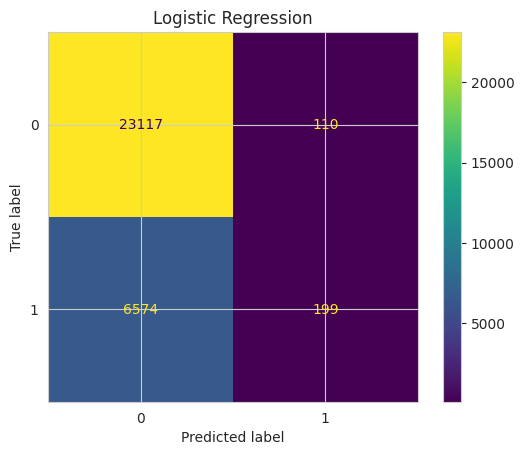

Decision Tree

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.96      0.96     23227
           1       0.87      0.90      0.88      6773

    accuracy                           0.95     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.95      0.95      0.95     30000



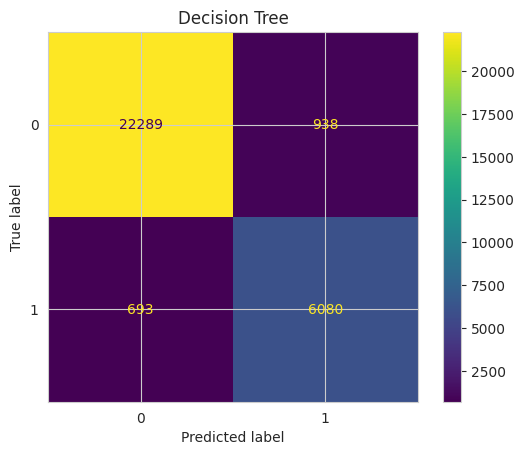

KNN

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.97      0.94     23227
           1       0.88      0.64      0.74      6773

    accuracy                           0.90     30000
   macro avg       0.89      0.81      0.84     30000
weighted avg       0.90      0.90      0.89     30000



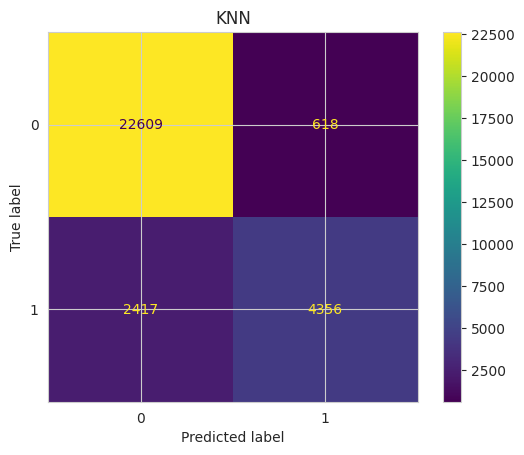

Naive Bayes

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.95      0.86     23227
           1       0.43      0.12      0.19      6773

    accuracy                           0.77     30000
   macro avg       0.61      0.54      0.53     30000
weighted avg       0.71      0.77      0.71     30000



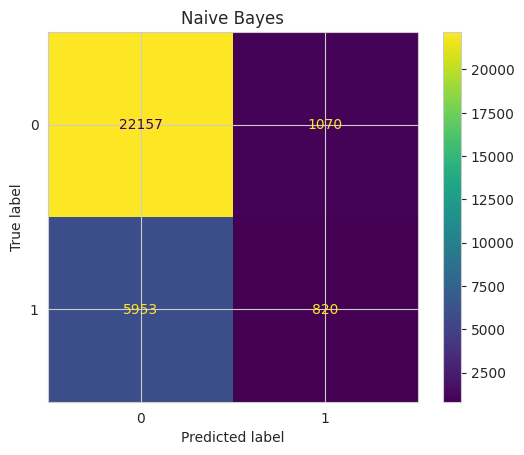

Random Forest

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     23227
           1       0.97      0.90      0.93      6773

    accuracy                           0.97     30000
   macro avg       0.97      0.95      0.96     30000
weighted avg       0.97      0.97      0.97     30000



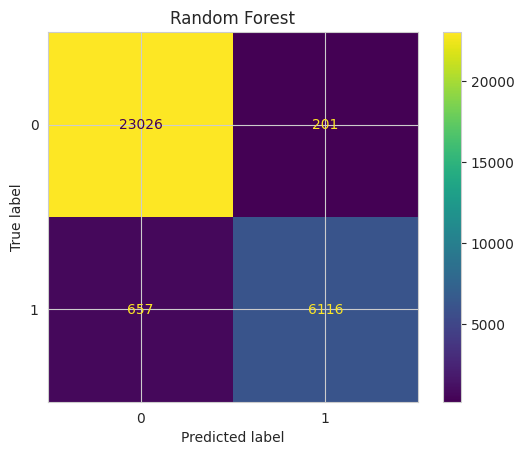

AdaBoost

Classification Report

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     23227
           1       0.97      0.44      0.61      6773

    accuracy                           0.87     30000
   macro avg       0.92      0.72      0.77     30000
weighted avg       0.89      0.87      0.85     30000



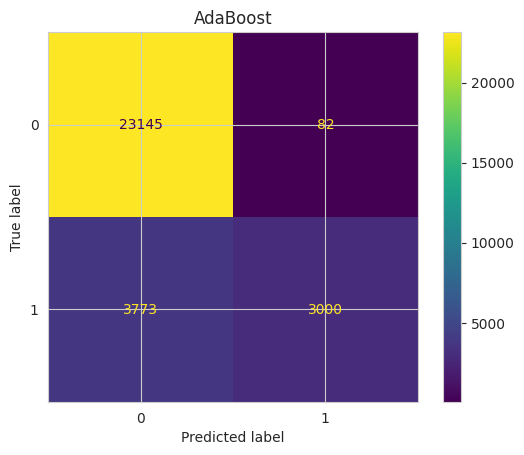

XGBoost

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     23227
           1       0.96      0.92      0.94      6773

    accuracy                           0.97     30000
   macro avg       0.97      0.95      0.96     30000
weighted avg       0.97      0.97      0.97     30000



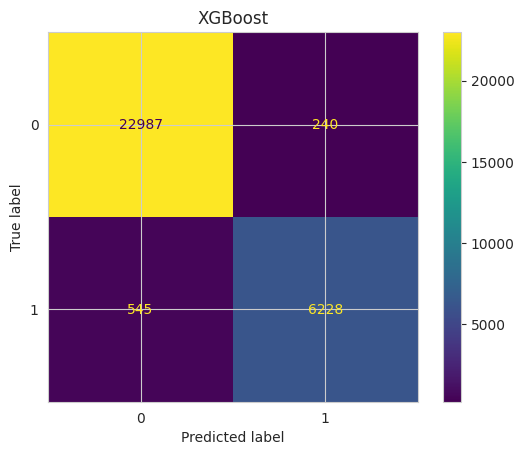

LightGBM

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     23227
           1       0.97      0.92      0.94      6773

    accuracy                           0.97     30000
   macro avg       0.97      0.96      0.96     30000
weighted avg       0.97      0.97      0.97     30000



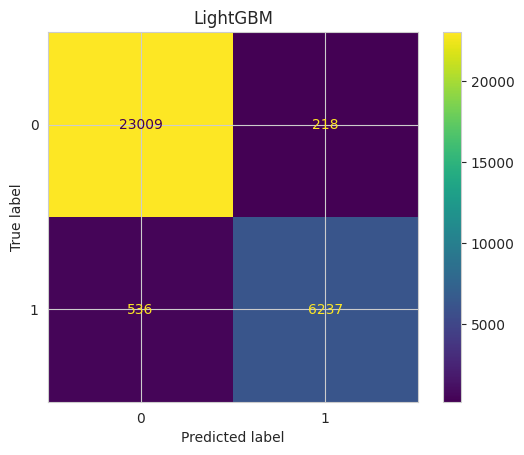

CatBoost

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     23227
           1       0.97      0.92      0.94      6773

    accuracy                           0.97     30000
   macro avg       0.97      0.96      0.96     30000
weighted avg       0.97      0.97      0.97     30000



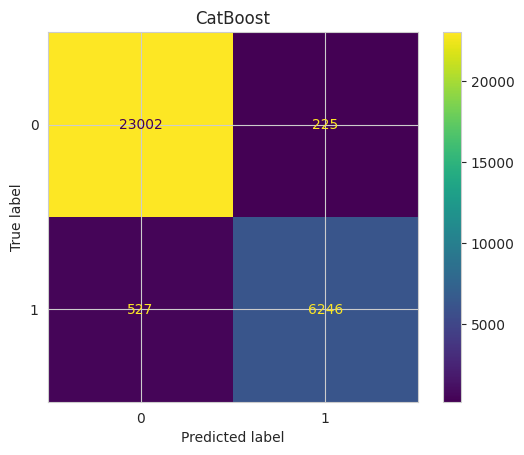

In [164]:
for name, model in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    trained_model, y_pred, metrics = evaluate_model(
        model,
        X_train_processed,
        y_train,
        X_val_processed,
        y_val
    )

    trained_models[name] = trained_model

    predictions[name] = y_pred

    print("\nClassification Report\n")
    print(classification_report(y_val, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred
    )

    plt.title(name)
    plt.show()

    metrics["Model"] = name

    results.append(metrics)

***4. Comparison table***

In [171]:
# ==========================================
# Model Comparison
# ==========================================

results_df = pd.DataFrame(results)

results_df = (
    results_df[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ]
    .sort_values("F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,CatBoost,0.9749,0.9652,0.9222,0.9432,0.9631
1,LightGBM,0.9749,0.9662,0.9209,0.9430,0.9637
2,XGBoost,0.9738,0.9629,0.9195,0.9407,0.9626
3,Random Forest,0.9714,0.9682,0.9030,0.9345,0.9629
4,Decision Tree,0.9456,0.8663,0.8977,0.8817,0.9286
5,KNN,0.8988,0.8758,0.6431,0.7416,0.8588
6,AdaBoost,0.8715,0.9734,0.4429,0.6088,0.9226
7,Naive Bayes,0.7659,0.4339,0.1211,0.1893,0.6664
8,Logistic Regression,0.7772,0.6440,0.0294,0.0562,0.6105


***5. F1-Score Comparison Chart***

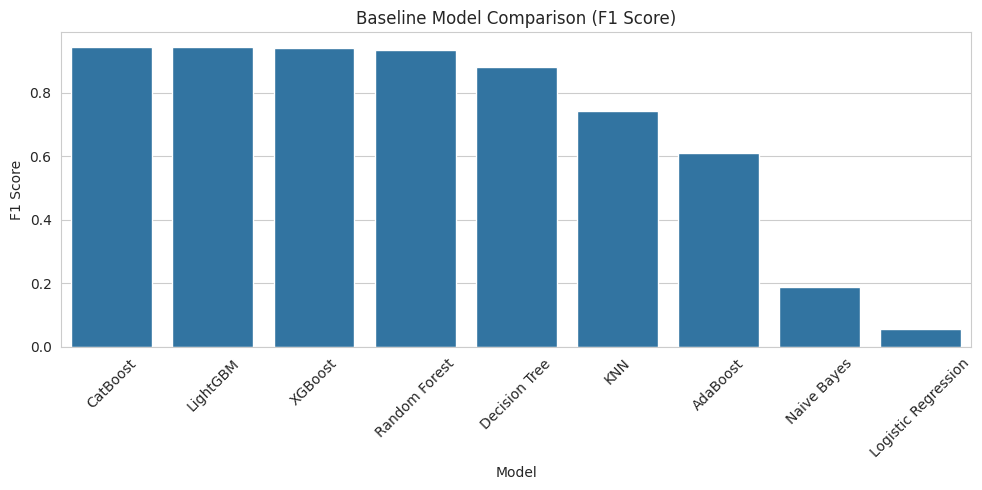

In [175]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)

plt.xticks(rotation=45)

plt.title("Baseline Model Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.show()

***6. Best Baseline Models***

In [208]:
best_model = results_df.iloc[0:3]

print("Best Baseline Model")
print(best_model)

Best Baseline Model
      Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  CatBoost  0.974933   0.965229  0.922191  0.943220  0.963126
1  LightGBM  0.974867   0.966228  0.920862  0.943000  0.963692
2   XGBoost  0.973833   0.962894  0.919533  0.940714  0.962630


### **Hyperparameter Tuning**
* The three best-performing baseline models (XGBoost, LightGBM and CatBoost) were further optimized using **RandomizedSearchCV**.

* Randomized Search was selected because it efficiently explores a larger hyperparameter space while requiring significantly less computation than Grid Search.

* The objective of this step is to improve the model's F1-score by identifying the optimal combination of hyperparameters.

* ***Remember:***
1. Train → Used to train the model.
2. Validation → Used for model selection and hyperparameter tuning.
3. Test → Used only once for the final unbiased evaluation.

***1. XGBoost Tuning***

In [177]:
xgb_params = {

    "n_estimators":[100,200,300],

    "max_depth":[3,5,7,9],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.8,0.9,1.0],

    "colsample_bytree":[0.8,0.9,1.0],

    "min_child_weight":[1,3,5]

}

In [179]:
#Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [180]:
# Search

xgb_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=xgb_params,

    n_iter=20,

    scoring="f1",

    cv=3,

    verbose=1,

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [182]:
# Best Parameters

print("Best Parameters for XGBoost:")
print(xgb_search.best_params_)
print("Best Score for XGBoost: ")
print(xgb_search.best_score_)

Best Parameters for XGBoost:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best Score for XGBoost: 
0.9392953445790191


In [184]:
# Best tuned model
best_xgb = xgb_search.best_estimator_

# Evaluate on validation set
_, y_pred, xgb_metrics = evaluate_model(
    best_xgb,
    X_train_processed,
    y_train,
    X_val_processed,
    y_val
)

print("\nValidation Metrics:")
print(xgb_metrics)


Validation Metrics:
{'Accuracy': 0.9752333333333333, 'Precision': 0.9661410018552876, 'Recall': 0.922633987893105, 'F1 Score': 0.9438864134128843, 'ROC-AUC': np.float64(0.9628785151174667)}


***2. LightGBM***

In [185]:
lgbm_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50, 70],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [186]:
lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1
)

In [187]:
lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

lgbm_search.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=LGBMClassifier(random_state=42, verbose=-1),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 10],
                                        'n_estimators': [100, 200, 300],
                                        'num_leaves': [31, 50, 70],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [188]:
best_lgbm = lgbm_search.best_estimator_

_, y_pred, lgbm_metrics = evaluate_model(
    best_lgbm,
    X_train_processed,
    y_train,
    X_val_processed,
    y_val
)

print("Best Parameters:")
print(lgbm_search.best_params_)

print("\nValidation Metrics:")
print(lgbm_metrics)

Best Parameters:
{'subsample': 0.9, 'num_leaves': 70, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Validation Metrics:
{'Accuracy': 0.9752666666666666, 'Precision': 0.9662903974021958, 'Recall': 0.922633987893105, 'F1 Score': 0.9439577039274925, 'ROC-AUC': np.float64(0.9632073173062725)}


***3. CatBoost***

In [189]:
cat_params = {
    "iterations": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128]
}

In [191]:
cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

In [192]:
cat_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=cat_params,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

cat_search.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=CatBoostClassifier(random_state=42, verbose=0),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'border_count': [32, 64, 128],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [100, 200, 300],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   random_state=42, scoring='f1', verbose=1)

In [193]:
print("Best Parameters:")
print(cat_search.best_params_)

print("\nBest Cross Validation F1:")
print(cat_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'l2_leaf_reg': 9, 'iterations': 300, 'depth': 8, 'border_count': 128}

Best Cross Validation F1:
0.9283995809902787


In [198]:
best_cat = cat_search.best_estimator_

_, y_pred, cat_metrics = evaluate_model(
    best_cat,
    X_train_processed,
    y_train,
    X_val_processed,
    y_val
)

print("\nValidation Metrics:")
print(cat_metrics)


Validation Metrics:
{'Accuracy': 0.9714, 'Precision': 0.9662620211256503, 'Recall': 0.9049165805403809, 'F1 Score': 0.934583714547118, 'ROC-AUC': np.float64(0.9628688975612731)}


In [195]:
tuned_results = pd.DataFrame([
    {"Model": "XGBoost", **xgb_metrics},
    {"Model": "LightGBM", **lgbm_metrics},
    {"Model": "CatBoost", **cat_metrics},
])

tuned_results = tuned_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(tuned_results.round(6))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.975267,0.966290,0.922634,0.943958,0.963207
1,XGBoost,0.975233,0.966141,0.922634,0.943886,0.962879
2,CatBoost,0.971400,0.966262,0.904917,0.934584,0.962869


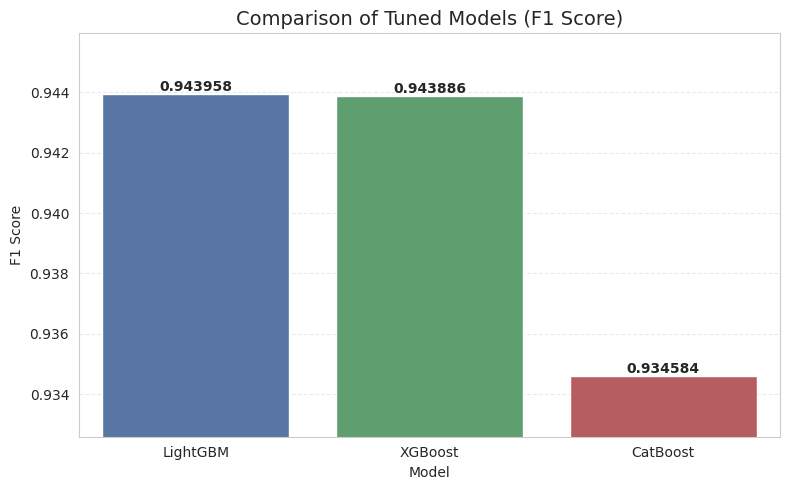

In [196]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tuned_results,
    x="Model",
    y="F1 Score",
    palette=["#4C72B0", "#55A868", "#C44E52"]
)

# Zoom the y-axis to highlight small differences
plt.ylim(
    tuned_results["F1 Score"].min() - 0.002,
    tuned_results["F1 Score"].max() + 0.002
)

# Display exact F1-score on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.6f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Comparison of Tuned Models (F1 Score)", fontsize=14)
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### ***Best Tuned Model Selection***

Among the three tuned gradient boosting models, **LightGBM** achieved the highest F1-score (0.943958) on the validation dataset. Therefore, LightGBM was selected as the final model for evaluation on the unseen test dataset.

### **Evaluation on Test Set**

In [200]:
# Evaluate best model on test dataset

y_test_pred = best_lgbm.predict(X_test_processed)
y_test_prob = best_lgbm.predict_proba(X_test_processed)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1 Score": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob)
}

print("Final Test Metrics")
print(final_metrics)

Final Test Metrics
{'Accuracy': 0.9756, 'Precision': 0.967551622418879, 'Recall': 0.9225758697261288, 'F1 Score': 0.9445286450439527, 'ROC-AUC': np.float64(0.9631071994184179)}


In [201]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     46490
           1       0.97      0.92      0.94     13510

    accuracy                           0.98     60000
   macro avg       0.97      0.96      0.96     60000
weighted avg       0.98      0.98      0.98     60000



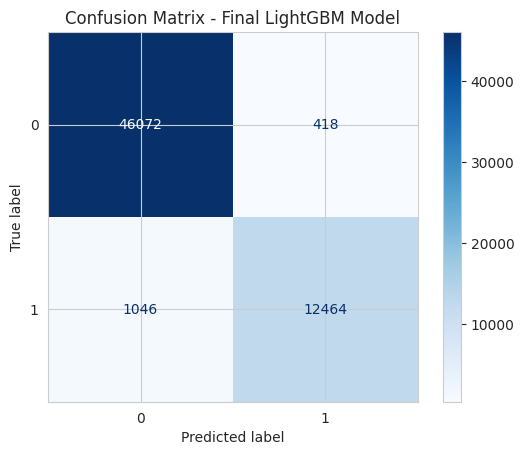

In [202]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Final LightGBM Model")
plt.show()

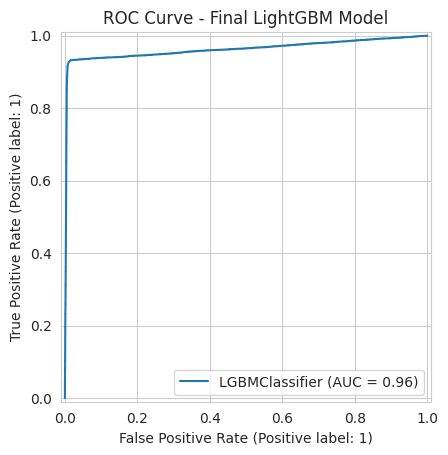

In [203]:
# ROC - Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_lgbm,
    X_test_processed,
    y_test
)

plt.title("ROC Curve - Final LightGBM Model")
plt.show()

In [204]:
final_results = pd.DataFrame([final_metrics])

display(final_results.round(6))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.9756,0.967552,0.922576,0.944529,0.963107


### **Saving the preprocessor & model pickle files**

In [205]:
joblib.dump(
    best_lgbm,
    "best_model.pkl"
)

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [206]:
# for database connectivity purpose
from joblib import load

preprocessor = load("preprocessor.pkl")

print("Feature Names:")
print(preprocessor.feature_names_in_)

print("\nNumber of Features:")
print(len(preprocessor.feature_names_in_))

Feature Names:
['invoice_amount' 'payment_terms' 'invoice_type' 'submission_hour'
 'supplier_invoice_count_30d' 'supplier_avg_amount_90d'
 'invoice_amount_zscore' 'late_night_submission_flag' 'supplier_country'
 'supplier_age_days' 'supplier_risk_score' 'blacklisted_flag'
 'avg_invoice_amount' 'region' 'annual_budget' 'invoice_month'
 'invoice_weekday' 'invoice_quarter' 'is_weekend' 'supplier_frequency']

Number of Features:
20


### Final Model Selection

* Three gradient boosting models (XGBoost, LightGBM and CatBoost) were optimized using Randomized Search.

* Among them, **LightGBM** achieved the highest F1-score on the validation dataset and demonstrated the best overall balance between Precision, Recall and ROC-AUC.

* The tuned LightGBM model was therefore selected as the final production model and evaluated on the unseen test dataset before deployment.